
## Computing Energy Conditions
### Get Metric and Energy Tensor

In [1]:
%% Alcubierre
gridSize = [1 20 20 20];
worldCenter = (gridSize+1)./2;
velocity = 0.5;
R = 5;
sigma = 0.5;
Metric = metricGet_AlcubierreComoving(gridSize,worldCenter,velocity,R,sigma);

% Compute energy tensor
EnergyTensor = getEnergyTensor(Metric);


### Get Energy Conditions Map

In [2]:
[nullEnergyCondition] = getEnergyConditions(EnergyTensor,Metric,"Null");
[weakEnergyCondition] = getEnergyConditions(EnergyTensor,Metric,"Weak");
[strongEnergyCondition] = getEnergyConditions(EnergyTensor,Metric,"Strong");
[dominantEnergyCondition] = getEnergyConditions(EnergyTensor,Metric,"Dominant");


### Plot Energy Conditions


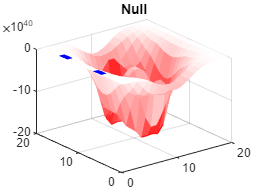

In [3]:
surfq(nullEnergyCondition(1,:,:,10),'EdgeColor','none')
title('Null')


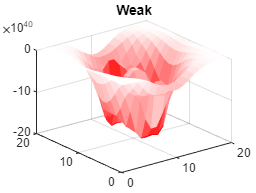

In [4]:

surfq(weakEnergyCondition(1,:,:,10),'EdgeColor','none')
title('Weak')


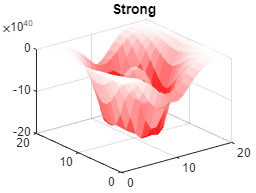

In [5]:

surfq(strongEnergyCondition(1,:,:,10),'EdgeColor','none')
title('Strong')


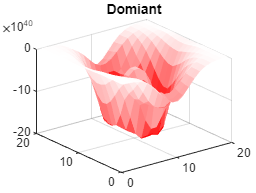

In [6]:

surfq(strongEnergyCondition(1,:,:,10),'EdgeColor','none')
title('Domiant')

### Returning Vectors

You can also return the energy conditions per vector sampled at each point in the spacetime by specifying the return vector option to true.


In [7]:
numAngularVec = 100;
numTimeVec = 10;

[nullMap, nullVecMap, vectorField] = getEnergyConditions(EnergyTensor,Metric,"Null",numAngularVec,numTimeVec,1);


We can now plot the violation amount scaled to a quiver plot along each of the sampled directions.



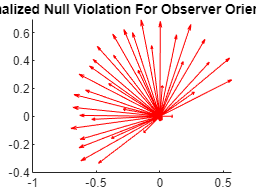

In [8]:
% Normalize the violation amount for plotting
nullVecMap = nullVecMap./max(abs(nullVecMap),[],'all');

% Define the spacetime point to sample
samplePoint = [1,5,5,5];

figure()
hold on
for i = 1:size(vectorField,2)
    quiver3(0,0,0, ...
        vectorField(2,i), vectorField(3,i), vectorField(4,i), ...
        nullVecMap(samplePoint(1),samplePoint(2),samplePoint(3),samplePoint(4),i),'r')
end
title('Normalized Null Violation For Observer Orientations')